# Problem 2.1 — Interactive arbitrage search with all calls and all puts

This Colab notebook implements an interactive version of the arbitrage-search workflow. The user does not edit a configuration cell before running the analysis. Instead, after running the final cell, the program asks for:

1. the ticker symbol,
2. the expiration date, selected after the available dates are downloaded and printed,
3. the transaction-cost perturbation.

Every call and every put returned by Yahoo Finance is treated as an independent traded instrument. Calls and puts are **not** matched by strike, and no common-strike filtering is performed.

## Cell 1 — Install the required packages

This cell installs the packages used by the notebook. `yfinance` downloads the option chain, `scipy` solves the mixed-integer linear program, `prettytable` prints tables in a style close to the original notebook, and `matplotlib` draws the terminal profit function.

In [1]:
%pip -q install yfinance prettytable scipy pandas matplotlib

## Cell 2 — Load the full implementation

This cell defines all helper functions used in the analysis. The main modelling choices are:

- all Yahoo calls are used as separate call instruments;
- all Yahoo puts are used as separate put instruments;
- calls and puts are not paired by strike;
- purchases are valued at ask prices and sales at bid prices;
- the transaction-cost perturbation widens the spread conservatively by increasing asks and decreasing bids;
- the output follows the same style as the uploaded arbitrage notebook: input summary, portfolio table, option-position table, conclusion, and payoff/profit graph.

The cell only defines functions. It does not ask the user for inputs yet.

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Problem 2.1 - Arbitrage detection with all Yahoo calls and all Yahoo puts.

This Colab-ready script follows the output style of the uploaded
FindingArbitrage.ipynb notebook:
- input summary,
- portfolio table,
- option-position table,
- arbitrage conclusion,
- payoff/profit plot.

Important modelling choices
---------------------------
1. Calls and puts are treated as independent instruments.
   There is no call-put matching by strike and no common-strike filtering.
   If Yahoo returns 80 calls and 74 puts, the MILP receives 154 independent
   option instruments.

2. The model uses bid-ask execution:
   - buying an option/share costs the ask,
   - selling an option/share receives the bid.

3. The user supplies an external transaction-cost perturbation.
   The perturbation widens the spread conservatively:
   - effective ask = ask * (1 + perturbation_percent / 100) + absolute_perturbation,
   - effective bid = max(0, bid * (1 - perturbation_percent / 100) - absolute_perturbation).

4. The main Colab workflow is interactive.
   The user runs run_interactive_analysis(), types the ticker, sees all
   available expiration dates, chooses one by number or exact date, and then
   types the transaction-cost perturbation.

Requirements
------------
numpy, pandas, scipy, yfinance, prettytable, matplotlib
"""

from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

try:
    import yfinance as yf
except Exception:
    yf = None

from scipy.optimize import Bounds, LinearConstraint, milp

try:
    from prettytable import PrettyTable
except Exception:
    PrettyTable = None


# =============================================================================
# User configuration
# =============================================================================

@dataclass
class UserConfig:
    """External inputs controlled by the user."""

    ticker: str
    expiration_date: str
    transaction_cost_perturbation_percent: float

    # If True, lastPrice is used as both bid and ask before perturbation.
    # If False, Yahoo bid and ask fields are used.
    use_last_price: bool = False

    # Annual risk-free rate in percent. Example: 4.0 means 4%.
    risk_free_rate_percent: float = 4.0

    # Initial capital V. For a zero-cost arbitrage search, use V=0.
    initial_capital: float = 0.0

    # Optional absolute spread widening in price units.
    absolute_perturbation: float = 0.0

    # Effective stock spread around spot before transaction-cost perturbation.
    # Example: 0.10 means an initial 0.10% full stock spread around spot.
    stock_spread_percent: float = 0.0

    # Total option-position limits.
    max_total_call_options_to_buy: int = 40
    max_total_call_options_to_sell: int = 40
    max_total_put_options_to_buy: int = 40
    max_total_put_options_to_sell: int = 40

    # Per-option limits. Each Yahoo option row is a separate instrument.
    max_call_options_to_buy_per_contract: int = 2
    max_call_options_to_sell_per_contract: int = 2
    max_put_options_to_buy_per_contract: int = 2
    max_put_options_to_sell_per_contract: int = 2

    # Stock buy/sell limits.
    max_shares_to_buy: float = 100.0
    max_shares_to_sell: float = 100.0

    # Bank-account bounds.
    max_deposit_limit: float = 1_000_000.0
    max_borrow_limit: float = 1_000_000.0

    # Numerical and plotting settings.
    solver_tolerance: float = 1e-8
    plot_points: int = 800
    high_price_multiplier: float = 3.0


# =============================================================================
# Expiration-date discovery and validation
# =============================================================================

def _require_yfinance() -> None:
    """Raise a clear error if yfinance is not available."""
    if yf is None:
        raise RuntimeError(
            "yfinance is not available. In Colab, run: "
            "!pip -q install yfinance prettytable scipy pandas matplotlib"
        )


def available_expirations(ticker: str) -> List[str]:
    """
    Return all option expiration dates currently listed by Yahoo Finance.

    The returned dates are strings in the format used by yfinance, for example
    '2026-06-19'.
    """
    _require_yfinance()
    clean_ticker = ticker.upper().strip()
    if not clean_ticker:
        raise ValueError("ticker must be a non-empty string.")

    stock = yf.Ticker(clean_ticker)
    dates = list(stock.options or [])
    if not dates:
        raise RuntimeError(
            f"No option expiration dates were returned for ticker {clean_ticker!r}. "
            "Check the ticker symbol or try again later."
        )
    return dates


def show_available_expiration_dates(ticker: str) -> List[str]:
    """
    Print a numbered list of available option expiration dates.

    The user should copy one of the printed dates into EXPIRATION_DATE.
    """
    dates = available_expirations(ticker)

    print("\n" + "=" * 78)
    print(f"Available expiration dates for {ticker.upper().strip()}")
    print("=" * 78)

    table = _make_table(["#", "Expiration date"])
    if table is not None:
        for i, d in enumerate(dates):
            table.add_row([i, d])
        print(table)
    else:
        display(pd.DataFrame({"#": range(len(dates)), "Expiration date": dates}))

    print("\nChoose one of these dates and set EXPIRATION_DATE in the next cell.")
    return dates


def validate_expiration_date(ticker: str, expiration_date: str, dates: Optional[Sequence[str]] = None) -> None:
    """
    Validate that expiration_date belongs to the available expiration list.

    This avoids silent errors caused by typos or stale dates.
    """
    if dates is None:
        dates = available_expirations(ticker)

    if expiration_date not in dates:
        preview = ", ".join(list(dates)[:20])
        more = " ..." if len(dates) > 20 else ""
        raise ValueError(
            f"Expiration date {expiration_date!r} is not available for {ticker.upper().strip()}.\n"
            f"Available dates include: {preview}{more}"
        )


# =============================================================================
# Data acquisition
# =============================================================================

def year_fraction_to_expiration(expiration_date: str) -> float:
    """
    Compute an ACT/365 year fraction from the current UTC time to expiration.

    For a date without an explicit time, the timestamp is interpreted at
    midnight UTC. The value is floored at zero.
    """
    expiry = pd.to_datetime(expiration_date).to_pydatetime()
    if expiry.tzinfo is None:
        expiry = expiry.replace(tzinfo=timezone.utc)
    now = datetime.now(timezone.utc)
    seconds = max((expiry - now).total_seconds(), 0.0)
    return seconds / (365.0 * 24.0 * 3600.0)


def _clean_option_side(df: pd.DataFrame, side: str, use_last_price: bool) -> pd.DataFrame:
    """
    Keep all valid option rows for one side of the chain.

    No matching against the other option side is performed. The only filtering
    is quote-quality filtering: finite strike, finite ask, finite bid,
    ask > 0, bid >= 0, and ask >= bid.
    """
    if df is None or df.empty:
        return pd.DataFrame(columns=["type", "strike", "lastPrice", "bid", "ask", "raw_bid", "raw_ask"])

    cols = ["strike", "lastPrice", "bid", "ask"]
    out = df.loc[:, [c for c in cols if c in df.columns]].copy()
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan

    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    out["type"] = side

    if use_last_price:
        # lastPrice is used as a frictionless quote before the artificial
        # transaction-cost perturbation is applied.
        out["raw_bid"] = out["lastPrice"]
        out["raw_ask"] = out["lastPrice"]
    else:
        out["raw_bid"] = out["bid"]
        out["raw_ask"] = out["ask"]

    out = out.dropna(subset=["strike", "raw_bid", "raw_ask"])
    out = out.query("strike > 0 and raw_ask > 0 and raw_bid >= 0 and raw_ask >= raw_bid")
    out = out.sort_values("strike").reset_index(drop=True)

    return out[["type", "strike", "lastPrice", "bid", "ask", "raw_bid", "raw_ask"]]


def fetch_option_chain_from_yahoo(
    ticker: str,
    expiration_date: str,
    use_last_price: bool = False,
    known_expirations: Optional[Sequence[str]] = None,
) -> Tuple[float, pd.DataFrame, pd.DataFrame]:
    """
    Download spot, calls, and puts from Yahoo Finance.

    Calls and puts are returned as separate dataframes. They are not merged,
    paired, or filtered by common strike.
    """
    _require_yfinance()

    clean_ticker = ticker.upper().strip()
    validate_expiration_date(clean_ticker, expiration_date, known_expirations)

    stock = yf.Ticker(clean_ticker)

    hist = stock.history(period="5d")
    close = hist.get("Close", pd.Series(dtype=float)).dropna()
    if close.empty:
        raise RuntimeError(f"Unable to fetch a recent spot price for {clean_ticker}.")
    spot = float(close.iloc[-1])

    chain = stock.option_chain(expiration_date)
    calls = _clean_option_side(chain.calls, "call", use_last_price)
    puts = _clean_option_side(chain.puts, "put", use_last_price)

    if calls.empty and puts.empty:
        raise RuntimeError(
            f"Yahoo returned no valid call or put quotes for {clean_ticker} "
            f"at expiration {expiration_date}."
        )

    return spot, calls, puts


# =============================================================================
# Bid-ask spread and transaction-cost perturbation
# =============================================================================

def apply_transaction_cost_perturbation(
    quotes: pd.DataFrame,
    perturbation_percent: float,
    absolute_perturbation: float = 0.0,
) -> pd.DataFrame:
    """
    Widen bid-ask spreads to account for transaction costs.

    The perturbation is conservative:
    - asks are increased,
    - bids are decreased but not allowed to become negative.
    """
    if perturbation_percent < 0:
        raise ValueError("transaction_cost_perturbation_percent must be nonnegative.")
    if absolute_perturbation < 0:
        raise ValueError("absolute_perturbation must be nonnegative.")

    out = quotes.copy()
    pct = float(perturbation_percent) / 100.0

    out["eff_ask"] = out["raw_ask"] * (1.0 + pct) + float(absolute_perturbation)
    out["eff_bid"] = np.maximum(0.0, out["raw_bid"] * (1.0 - pct) - float(absolute_perturbation))

    # Keep only quotes that remain economically meaningful.
    out = out.query("eff_ask > 0 and eff_bid >= 0 and eff_ask >= eff_bid").copy()
    out = out.reset_index(drop=True)
    return out


def effective_stock_bid_ask(
    spot: float,
    stock_spread_percent: float,
    perturbation_percent: float,
) -> Tuple[float, float]:
    """
    Construct effective stock bid and ask prices.

    yfinance usually supplies a recent spot/close price rather than a
    synchronized stock bid/ask pair. We therefore create a symmetric spread
    around spot and then apply the same conservative perturbation.
    """
    if spot <= 0:
        raise ValueError("spot must be positive.")
    if stock_spread_percent < 0:
        raise ValueError("stock_spread_percent must be nonnegative.")
    if perturbation_percent < 0:
        raise ValueError("transaction_cost_perturbation_percent must be nonnegative.")

    half = float(stock_spread_percent) / 200.0
    pct = float(perturbation_percent) / 100.0

    base_bid = float(spot) * (1.0 - half)
    base_ask = float(spot) * (1.0 + half)

    eff_bid = max(0.0, base_bid * (1.0 - pct))
    eff_ask = base_ask * (1.0 + pct)

    if eff_ask < eff_bid:
        raise RuntimeError("Effective stock ask became smaller than effective stock bid.")
    return eff_bid, eff_ask


# =============================================================================
# MILP model
# =============================================================================

def _payoff_row(
    y: float,
    call_strikes: np.ndarray,
    put_strikes: np.ndarray,
    bank_growth: float,
) -> np.ndarray:
    """
    Terminal payoff row for the MILP decision variables.

    Variable order:
    [call_buy(m), call_sell(m),
     put_buy(n), put_sell(n),
     share_buy, share_sell,
     bank, z]

    The actual net stock position is share_buy - share_sell.
    The auxiliary variable z is included with coefficient 1 in the payoff
    constraint but is not part of the real portfolio payoff.
    """
    call_pay = np.maximum(y - call_strikes, 0.0)
    put_pay = np.maximum(put_strikes - y, 0.0)

    return np.concatenate([
        call_pay,                       # long calls
        -call_pay,                      # short calls
        put_pay,                        # long puts
        -put_pay,                       # short puts
        np.array([y], dtype=float),     # long shares
        np.array([-y], dtype=float),    # short shares
        np.array([bank_growth], dtype=float),
        np.array([1.0], dtype=float),   # z
    ])


def build_and_solve_arbitrage_milp(
    spot: float,
    stock_bid: float,
    stock_ask: float,
    calls: pd.DataFrame,
    puts: pd.DataFrame,
    config: UserConfig,
    T: float,
) -> Dict[str, object]:
    """
    Build and solve the MILP arbitrage-search model.

    Every call row and every put row is used independently. The only common
    object is the terminal payoff grid, which consists of zero, all call
    strikes, all put strikes, and a large point used for tail safety.
    """
    call_strikes = calls["strike"].to_numpy(float)
    put_strikes = puts["strike"].to_numpy(float)

    call_ask = calls["eff_ask"].to_numpy(float)
    call_bid = calls["eff_bid"].to_numpy(float)
    put_ask = puts["eff_ask"].to_numpy(float)
    put_bid = puts["eff_bid"].to_numpy(float)

    m = len(call_strikes)
    n = len(put_strikes)

    if m == 0 and n == 0:
        raise RuntimeError("No option instruments remain after quote filtering.")

    r = float(config.risk_free_rate_percent) / 100.0
    bank_growth = (1.0 + r) ** float(T)

    # A portfolio made of calls, puts, stock, and bank account has a
    # piecewise-affine terminal payoff. It is enough to test all breakpoints.
    base_grid = np.unique(np.concatenate([
        np.array([0.0], dtype=float),
        call_strikes,
        put_strikes,
    ]))

    max_reference = max(float(spot), float(base_grid.max()), 1.0)
    S_high = float(config.high_price_multiplier) * max_reference
    grid = np.unique(np.append(base_grid, S_high))

    L = 2 * m + 2 * n + 4
    share_buy_idx = 2 * m + 2 * n
    share_sell_idx = share_buy_idx + 1
    bank_idx = share_sell_idx + 1
    z_idx = bank_idx + 1

    # Payoff constraints:
    # terminal payoff + z >= V at every grid point.
    # Equivalently: -(terminal payoff + z) <= -V.
    payoff_rows = np.vstack([
        -_payoff_row(float(y), call_strikes, put_strikes, bank_growth)
        for y in grid
    ])
    lb_payoff = np.full(len(grid), -np.inf, dtype=float)
    ub_payoff = np.full(len(grid), -float(config.initial_capital), dtype=float)

    # Tail-slope guard for S -> infinity:
    # slope = net shares + long calls - short calls >= 0.
    A_slope = np.zeros(L)
    A_slope[0:m] = 1.0
    A_slope[m:2*m] = -1.0
    A_slope[share_buy_idx] = 1.0
    A_slope[share_sell_idx] = -1.0

    # Initial budget equality:
    # pay asks when buying, receive bids when selling, and use the bank account
    # to make the initial cashflow equal to V.
    A_cost = np.zeros(L)
    A_cost[0:m] = call_ask
    A_cost[m:2*m] = -call_bid
    A_cost[2*m:2*m+n] = put_ask
    A_cost[2*m+n:2*m+2*n] = -put_bid
    A_cost[share_buy_idx] = stock_ask
    A_cost[share_sell_idx] = -stock_bid
    A_cost[bank_idx] = 1.0

    # Total position-limit constraints, matching the original notebook style.
    A_tot_call_buy = np.zeros(L);  A_tot_call_buy[0:m] = 1.0
    A_tot_call_sell = np.zeros(L); A_tot_call_sell[m:2*m] = 1.0
    A_tot_put_buy = np.zeros(L);   A_tot_put_buy[2*m:2*m+n] = 1.0
    A_tot_put_sell = np.zeros(L);  A_tot_put_sell[2*m+n:2*m+2*n] = 1.0

    A = np.vstack([
        payoff_rows,
        A_slope[None, :],
        A_cost[None, :],
        A_tot_call_buy[None, :],
        A_tot_call_sell[None, :],
        A_tot_put_buy[None, :],
        A_tot_put_sell[None, :],
    ])

    lb = np.concatenate([
        lb_payoff,
        np.array([0.0]),                          # slope lower bound
        np.array([float(config.initial_capital)]), # budget equality
        np.full(4, -np.inf),                      # no lower bound on totals
    ])

    ub = np.concatenate([
        ub_payoff,
        np.array([np.inf]),                       # slope upper bound
        np.array([float(config.initial_capital)]), # budget equality
        np.array([
            float(config.max_total_call_options_to_buy),
            float(config.max_total_call_options_to_sell),
            float(config.max_total_put_options_to_buy),
            float(config.max_total_put_options_to_sell),
        ]),
    ])

    constraints = LinearConstraint(A, lb, ub)

    lower = np.zeros(L)
    upper = np.full(L, np.inf)

    # Per-instrument option bounds.
    upper[0:m] = float(config.max_call_options_to_buy_per_contract)
    upper[m:2*m] = float(config.max_call_options_to_sell_per_contract)
    upper[2*m:2*m+n] = float(config.max_put_options_to_buy_per_contract)
    upper[2*m+n:2*m+2*n] = float(config.max_put_options_to_sell_per_contract)

    # Share buy/sell bounds.
    upper[share_buy_idx] = float(config.max_shares_to_buy)
    upper[share_sell_idx] = float(config.max_shares_to_sell)

    # Bank bounds.
    lower[bank_idx] = -float(config.max_borrow_limit)
    upper[bank_idx] = float(config.max_deposit_limit)

    # z is continuous and free.
    lower[z_idx] = -np.inf
    upper[z_idx] = np.inf

    bounds = Bounds(lower, upper)

    # Options are integer quantities. Stock, bank, and z are continuous.
    integrality = np.ones(L, dtype=int)
    integrality[share_buy_idx] = 0
    integrality[share_sell_idx] = 0
    integrality[bank_idx] = 0
    integrality[z_idx] = 0

    # Objective: minimize z. If z < 0, the portfolio has a positive guaranteed
    # payoff buffer of at least -z over the tested payoff grid and tail guard.
    c = np.zeros(L)
    c[z_idx] = 1.0

    res = milp(c=c, constraints=constraints, integrality=integrality, bounds=bounds)

    if res.x is None:
        raise RuntimeError(f"MILP did not return a solution. Status={res.status}, message={res.message}")

    return {
        "solution": res.x,
        "status": res.status,
        "message": res.message,
        "call_strikes": call_strikes,
        "put_strikes": put_strikes,
        "call_ask": call_ask,
        "call_bid": call_bid,
        "put_ask": put_ask,
        "put_bid": put_bid,
        "calls_table": calls,
        "puts_table": puts,
        "bank_growth": bank_growth,
        "grid": grid,
        "S_high": S_high,
        "share_buy_idx": share_buy_idx,
        "share_sell_idx": share_sell_idx,
        "bank_idx": bank_idx,
        "z_idx": z_idx,
        "stock_bid": stock_bid,
        "stock_ask": stock_ask,
        "spot": spot,
        "T": T,
    }


# =============================================================================
# Reporting, tables, and plotting
# =============================================================================

def _make_table(field_names: Sequence[str]):
    """Create a PrettyTable when available; otherwise return None."""
    if PrettyTable is None:
        return None
    return PrettyTable(field_names)


def profit_at_expiry(y: float, result: Dict[str, object], config: UserConfig) -> float:
    """Evaluate the true terminal profit at stock price y, excluding z."""
    x = result["solution"]
    row = _payoff_row(
        float(y),
        result["call_strikes"],
        result["put_strikes"],
        result["bank_growth"],
    )
    return float(np.dot(row[:-1], x[:-1]) - float(config.initial_capital))


def print_quote_summary(
    spot: float,
    stock_bid: float,
    stock_ask: float,
    calls: pd.DataFrame,
    puts: pd.DataFrame,
    config: UserConfig,
    T: float,
) -> None:
    """Print a compact summary of the input quotes used by the model."""
    print("\n" + "=" * 78)
    print("Input summary")
    print("=" * 78)
    print(f"Ticker: {config.ticker.upper().strip()}")
    print(f"Expiration date: {config.expiration_date}")
    print(f"Time to expiry T: {T:.8f} years")
    print(f"Spot: {spot:.6f}")
    print(f"Effective stock bid/ask: {stock_bid:.6f} / {stock_ask:.6f}")
    print(f"Risk-free rate: {config.risk_free_rate_percent:.6f}%")
    print(f"Initial capital V: {config.initial_capital:.6f}")
    print(f"Transaction-cost perturbation: {config.transaction_cost_perturbation_percent:.6f}%")
    print(f"Absolute perturbation: {config.absolute_perturbation:.6f}")
    print(f"Calls used: {len(calls)}")
    print(f"Puts used: {len(puts)}")
    print("Calls and puts are used independently. No common-strike matching is performed.")


def print_portfolio_tables(result: Dict[str, object], config: UserConfig) -> None:
    """Print the same type of tables as in the uploaded notebook."""
    x = result["solution"]
    ticker = config.ticker.upper().strip()

    call_strikes = result["call_strikes"]
    put_strikes = result["put_strikes"]
    call_ask = result["call_ask"]
    call_bid = result["call_bid"]
    put_ask = result["put_ask"]
    put_bid = result["put_bid"]

    m = len(call_strikes)
    n = len(put_strikes)

    share_buy_idx = result["share_buy_idx"]
    share_sell_idx = result["share_sell_idx"]
    bank_idx = result["bank_idx"]

    share_buy = float(x[share_buy_idx])
    share_sell = float(x[share_sell_idx])
    net_shares = share_buy - share_sell
    stock_cashflow = share_buy * float(result["stock_ask"]) - share_sell * float(result["stock_bid"])

    print("\n" + "=" * 78)
    print("Portfolio table")
    print("=" * 78)

    tb = _make_table(["Asset", "Qty/Amount", "Unit/Info", "Initial Cashflow"])
    if tb is not None:
        tb.add_row([
            ticker + " (Net Shares)",
            round(net_shares, 6),
            f"buy@ask={result['stock_ask']:.6f}, sell@bid={result['stock_bid']:.6f}",
            round(stock_cashflow, 6),
        ])
        tb.add_row([
            "Bank account",
            round(float(x[bank_idx]), 6),
            f"g=(1+r)^T={result['bank_growth']:.6f}",
            round(float(x[bank_idx]), 6),
        ])
        print(tb)
    else:
        display(pd.DataFrame([
            {
                "Asset": ticker + " (Net Shares)",
                "Qty/Amount": round(net_shares, 6),
                "Unit/Info": f"buy@ask={result['stock_ask']:.6f}, sell@bid={result['stock_bid']:.6f}",
                "Initial Cashflow": round(stock_cashflow, 6),
            },
            {
                "Asset": "Bank account",
                "Qty/Amount": round(float(x[bank_idx]), 6),
                "Unit/Info": f"g=(1+r)^T={result['bank_growth']:.6f}",
                "Initial Cashflow": round(float(x[bank_idx]), 6),
            },
        ]))

    print("\n" + "=" * 78)
    print("Option-position table")
    print("=" * 78)

    tt = _make_table(["Type", "Strike", "Qty", "Price each", "Initial Cashflow"])
    rows = []

    for i in range(m):
        qty = int(round(x[i]))
        if qty > 0:
            rows.append(["Call (buy)", call_strikes[i], qty, call_ask[i], qty * call_ask[i]])

    for i in range(m):
        j = m + i
        qty = int(round(x[j]))
        if qty > 0:
            rows.append(["Call (sell)", call_strikes[i], qty, call_bid[i], -qty * call_bid[i]])

    for i in range(n):
        j = 2 * m + i
        qty = int(round(x[j]))
        if qty > 0:
            rows.append(["Put (buy)", put_strikes[i], qty, put_ask[i], qty * put_ask[i]])

    for i in range(n):
        j = 2 * m + n + i
        qty = int(round(x[j]))
        if qty > 0:
            rows.append(["Put (sell)", put_strikes[i], qty, put_bid[i], -qty * put_bid[i]])

    total_option_cashflow = float(sum(row[4] for row in rows))

    if tt is not None:
        for row in rows:
            tt.add_row([
                row[0],
                round(float(row[1]), 6),
                row[2],
                round(float(row[3]), 6),
                round(float(row[4]), 6),
            ])
        if rows:
            tt.add_divider()
        tt.add_row(["Total amount", "--", "--", "--", round(total_option_cashflow, 6)])
        print(tt)
    else:
        if rows:
            display(pd.DataFrame(rows, columns=["Type", "Strike", "Qty", "Price each", "Initial Cashflow"]))
        else:
            print("No option positions selected.")
        print("Total option cashflow:", round(total_option_cashflow, 6))

    total_initial_cashflow = (
        total_option_cashflow
        + stock_cashflow
        + float(x[bank_idx])
    )
    print(f"\nTotal initial cashflow, including stock and bank: {total_initial_cashflow:.8f}")


def print_conclusion(result: Dict[str, object], config: UserConfig) -> None:
    """Print the same conclusion logic as the uploaded notebook."""
    x = result["solution"]
    z = float(x[result["z_idx"]])

    baseline_profit = float(config.initial_capital) * (float(result["bank_growth"]) - 1.0)
    tol = float(config.solver_tolerance)

    m = len(result["call_strikes"])
    n = len(result["put_strikes"])

    opt_sum = float(
        np.sum(x[0:m])
        + np.sum(x[m:2*m])
        + np.sum(x[2*m:2*m+n])
        + np.sum(x[2*m+n:2*m+2*n])
    )

    share_buy = float(x[result["share_buy_idx"]])
    share_sell = float(x[result["share_sell_idx"]])
    bank = float(x[result["bank_idx"]])

    pure_bank = (
        share_buy <= tol
        and share_sell <= tol
        and opt_sum <= tol
        and abs(bank - float(config.initial_capital)) <= 1e-6
    )

    print("\n" + "=" * 78)
    print("Arbitrage conclusion")
    print("=" * 78)

    if pure_bank:
        print("[CONCLUSION] All capital deposited in bank.")
        print("Profit at expiry = interest =", round(baseline_profit, 8))
        print("Not an arbitrage.")
        return

    if z > tol:
        print("[CONCLUSION] No portfolio found with guaranteed profit against V.")
        print("Maximum possible loss z =", round(z, 8))
        print("Bank interest baseline =", round(baseline_profit, 8))
    else:
        worst_case_profit = -z
        print("[CONCLUSION] Guaranteed profit (>=) =", round(worst_case_profit, 8))
        print("Bank interest baseline =", round(baseline_profit, 8))
        if worst_case_profit > baseline_profit + 1e-9:
            print("=> Arbitrage against deposit: exceeds interest by", round(worst_case_profit - baseline_profit, 8))
        else:
            print("=> Not arbitrage against deposit: does not exceed interest.")


def plot_profit_function(result: Dict[str, object], config: UserConfig) -> None:
    """Plot terminal profit as a function of the stock price at expiration."""
    y_max = float(max(result["S_high"], result["spot"] * 1.5))
    y_vals = np.linspace(0.0, y_max, int(config.plot_points))
    profits = np.array([profit_at_expiry(y, result, config) for y in y_vals])

    fig = plt.figure(figsize=(10, 6))
    ax = fig.gca()
    ax.plot(y_vals, profits)
    ax.set_xlabel("Stock Price at Expiration")
    ax.set_ylabel("Profit at Expiry")
    ax.set_title("Profit Function with Bank Account, All Calls, and All Puts")
    ax.grid(True)
    ax.axhline(0.0, linewidth=1.5, linestyle="--")
    ax.fill_between(y_vals, profits, 0.0, where=(profits > 0.0), alpha=0.3, label="Profit")
    ax.fill_between(y_vals, profits, 0.0, where=(profits < 0.0), alpha=0.3, label="Loss")
    ax.legend()
    plt.show()


def display_used_quotes(calls: pd.DataFrame, puts: pd.DataFrame, max_rows: int = 20) -> None:
    """
    Display the first rows of the effective quotes used in the model.

    This is optional but useful for verifying that calls and puts were not
    matched by strike.
    """
    cols = ["type", "strike", "raw_bid", "raw_ask", "eff_bid", "eff_ask"]
    all_quotes = pd.concat([calls[cols], puts[cols]], ignore_index=True)
    print(f"Displaying the first {min(max_rows, len(all_quotes))} of {len(all_quotes)} option instruments.")
    display(all_quotes.head(max_rows))


# =============================================================================
# End-to-end runner
# =============================================================================

def build_config_from_external_inputs(
    ticker: str,
    expiration_date: str,
    transaction_cost_perturbation_percent: float,
    **kwargs,
) -> UserConfig:
    """
    Build a UserConfig object from external variables.

    This function is useful in Colab because the user can edit a small cell with
    TICKER, EXPIRATION_DATE, and TRANSACTION_COST_PERTURBATION_PERCENT, then
    build the configuration object from those variables.
    """
    return UserConfig(
        ticker=ticker.upper().strip(),
        expiration_date=str(expiration_date),
        transaction_cost_perturbation_percent=float(transaction_cost_perturbation_percent),
        **kwargs,
    )


def run_analysis(config: UserConfig, known_expirations: Optional[Sequence[str]] = None) -> Dict[str, object]:
    """
    Run the full arbitrage analysis.

    The function assumes the user has already selected a valid expiration date
    from the list produced by show_available_expiration_dates().
    """
    validate_expiration_date(config.ticker, config.expiration_date, known_expirations)

    spot, calls_raw, puts_raw = fetch_option_chain_from_yahoo(
        ticker=config.ticker,
        expiration_date=config.expiration_date,
        use_last_price=config.use_last_price,
        known_expirations=known_expirations,
    )

    T = year_fraction_to_expiration(config.expiration_date)

    calls = apply_transaction_cost_perturbation(
        calls_raw,
        perturbation_percent=config.transaction_cost_perturbation_percent,
        absolute_perturbation=config.absolute_perturbation,
    )
    puts = apply_transaction_cost_perturbation(
        puts_raw,
        perturbation_percent=config.transaction_cost_perturbation_percent,
        absolute_perturbation=config.absolute_perturbation,
    )

    stock_bid, stock_ask = effective_stock_bid_ask(
        spot=spot,
        stock_spread_percent=config.stock_spread_percent,
        perturbation_percent=config.transaction_cost_perturbation_percent,
    )

    print_quote_summary(spot, stock_bid, stock_ask, calls, puts, config, T)

    result = build_and_solve_arbitrage_milp(
        spot=spot,
        stock_bid=stock_bid,
        stock_ask=stock_ask,
        calls=calls,
        puts=puts,
        config=config,
        T=T,
    )

    print_portfolio_tables(result, config)
    print_conclusion(result, config)
    plot_profit_function(result, config)

    result["calls"] = calls
    result["puts"] = puts
    result["config"] = config
    return result



# =============================================================================
# Interactive Colab runner
# =============================================================================

def _read_nonempty_text(prompt: str) -> str:
    """Read a non-empty string from the user."""
    while True:
        value = input(prompt).strip()
        if value:
            return value
        print("Please enter a non-empty value.")


def _read_float(prompt: str, default: Optional[float] = None, minimum: Optional[float] = None) -> float:
    """Read a floating-point value from the user, with optional default/minimum."""
    while True:
        suffix = f" [default: {default}]" if default is not None else ""
        raw = input(prompt + suffix + ": ").strip()
        if raw == "" and default is not None:
            value = float(default)
        else:
            try:
                value = float(raw)
            except ValueError:
                print("Please enter a valid number.")
                continue
        if minimum is not None and value < minimum:
            print(f"Please enter a value >= {minimum}.")
            continue
        return value


def _read_bool(prompt: str, default: bool = False) -> bool:
    """Read a yes/no answer from the user."""
    default_text = "y" if default else "n"
    while True:
        raw = input(f"{prompt} [y/n, default: {default_text}]: ").strip().lower()
        if raw == "":
            return default
        if raw in {"y", "yes"}:
            return True
        if raw in {"n", "no"}:
            return False
        print("Please answer y or n.")


def _choose_expiration_date_interactively(ticker: str, dates: Sequence[str]) -> str:
    """
    Ask the user to choose an expiration date after the dates have been shown.

    The user may type either the numeric index printed in the table or the exact
    expiration-date string.
    """
    if not dates:
        raise ValueError("No expiration dates are available.")

    while True:
        raw = input("Choose expiration date by number or exact YYYY-MM-DD date: ").strip()
        if raw.isdigit():
            idx = int(raw)
            if 0 <= idx < len(dates):
                return str(dates[idx])
            print(f"Please enter a number between 0 and {len(dates) - 1}.")
            continue

        if raw in dates:
            return raw

        print(f"{raw!r} is not one of the available expiration dates for {ticker.upper()}.")


def run_interactive_analysis(
    default_risk_free_rate_percent: float = 4.0,
    default_initial_capital: float = 0.0,
    default_use_last_price: bool = False,
    default_stock_spread_percent: float = 0.0,
    default_absolute_perturbation: float = 0.0,
    ask_advanced_settings: bool = False,
) -> Dict[str, object]:
    """
    Run the full workflow through Colab prompts.

    This is the intended workflow when the user wants to make all choices after
    executing the program:
    1. Type a ticker.
    2. The program downloads and prints all available option expiration dates.
    3. Choose one expiration date by number or exact date.
    4. Type the transaction-cost perturbation.
    5. The program downloads all calls and all puts for that expiration and runs
       the arbitrage-search MILP.
    """
    print("=" * 78)
    print("Interactive Problem 2.1 arbitrage search")
    print("=" * 78)
    print("You will now choose the inputs after running the cell.")
    print("Calls and puts will be treated as independent instruments.")
    print("No common-strike matching will be performed.\n")

    ticker = _read_nonempty_text("Enter ticker symbol, e.g. AAPL: ").upper().strip()

    print("\nFetching available expiration dates...")
    dates = show_available_expiration_dates(ticker)
    expiration_date = _choose_expiration_date_interactively(ticker, dates)

    perturbation = _read_float(
        "Enter transaction-cost perturbation percent. Example: 1 means asks increase by 1% and bids decrease by 1%",
        default=0.0,
        minimum=0.0,
    )

    if ask_advanced_settings:
        risk_free_rate_percent = _read_float(
            "Annual risk-free rate in percent",
            default=default_risk_free_rate_percent,
        )
        initial_capital = _read_float(
            "Initial capital V",
            default=default_initial_capital,
        )
        use_last_price = _read_bool(
            "Use lastPrice as both bid and ask before perturbation?",
            default=default_use_last_price,
        )
        stock_spread_percent = _read_float(
            "Initial stock spread percent around spot",
            default=default_stock_spread_percent,
            minimum=0.0,
        )
        absolute_perturbation = _read_float(
            "Absolute perturbation in price units",
            default=default_absolute_perturbation,
            minimum=0.0,
        )
    else:
        risk_free_rate_percent = float(default_risk_free_rate_percent)
        initial_capital = float(default_initial_capital)
        use_last_price = bool(default_use_last_price)
        stock_spread_percent = float(default_stock_spread_percent)
        absolute_perturbation = float(default_absolute_perturbation)

    cfg = build_config_from_external_inputs(
        ticker=ticker,
        expiration_date=expiration_date,
        transaction_cost_perturbation_percent=perturbation,
        use_last_price=use_last_price,
        risk_free_rate_percent=risk_free_rate_percent,
        initial_capital=initial_capital,
        absolute_perturbation=absolute_perturbation,
        stock_spread_percent=stock_spread_percent,
    )

    print("\nSelected inputs")
    print("-" * 78)
    print(f"Ticker: {cfg.ticker}")
    print(f"Expiration date: {cfg.expiration_date}")
    print(f"Transaction-cost perturbation: {cfg.transaction_cost_perturbation_percent}%")
    print(f"Risk-free rate: {cfg.risk_free_rate_percent}%")
    print(f"Initial capital: {cfg.initial_capital}")
    print("-" * 78)

    return run_analysis(cfg, known_expirations=dates)

## Cell 3 — Run the interactive analysis

Run this cell to make all choices interactively. The program will first ask for the ticker. Then it will download and display the available expiration dates. After that, choose one expiration date by entering either its number from the printed table or the exact date string. Finally, enter the transaction-cost perturbation percentage.

For example, a perturbation of `1` means:

- effective ask = ask × 1.01,
- effective bid = bid × 0.99.

This is a conservative way to account for transaction costs or additional spread widening.

Interactive Problem 2.1 arbitrage search
You will now choose the inputs after running the cell.
Calls and puts will be treated as independent instruments.
No common-strike matching will be performed.

Enter ticker symbol, e.g. AAPL: AAPL

Fetching available expiration dates...

Available expiration dates for AAPL
+----+-----------------+
| #  | Expiration date |
+----+-----------------+
| 0  |    2026-04-27   |
| 1  |    2026-04-29   |
| 2  |    2026-05-01   |
| 3  |    2026-05-04   |
| 4  |    2026-05-08   |
| 5  |    2026-05-15   |
| 6  |    2026-05-22   |
| 7  |    2026-05-29   |
| 8  |    2026-06-18   |
| 9  |    2026-07-17   |
| 10 |    2026-08-21   |
| 11 |    2026-09-18   |
| 12 |    2026-10-16   |
| 13 |    2026-11-20   |
| 14 |    2026-12-18   |
| 15 |    2027-01-15   |
| 16 |    2027-03-19   |
| 17 |    2027-06-17   |
| 18 |    2027-12-17   |
| 19 |    2028-01-21   |
| 20 |    2028-03-17   |
| 21 |    2028-12-15   |
+----+-----------------+

Choose one of these dates and set 

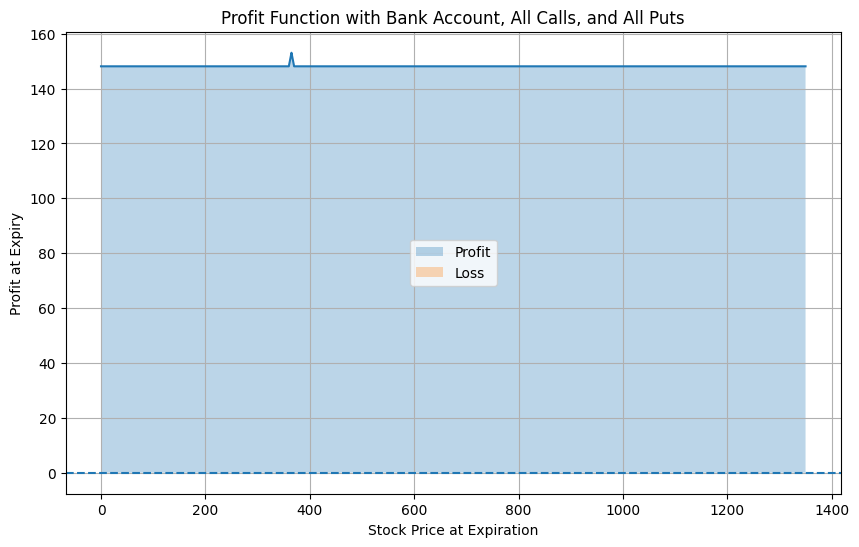

In [3]:
results = run_interactive_analysis()

## Optional Cell 4 — Run with advanced prompts

The standard interactive run asks only for the three requested user choices: ticker, expiration date, and transaction-cost perturbation. Run the optional cell below only if you also want to enter the risk-free rate, initial capital, whether to use `lastPrice`, a stock spread, and an absolute perturbation.

In [4]:
# Uncomment and run this cell if you want advanced prompts as well.
# results = run_interactive_analysis(ask_advanced_settings=True)

## Optional Cell 5 — Inspect the exact option quotes used

After the interactive analysis has finished, this optional cell displays the effective option quotes actually passed to the MILP. This is useful for verifying that all calls and all puts were used independently, without matching calls and puts by strike.

In [5]:
# Uncomment after running the analysis if you want to inspect the effective quotes.
# display_used_quotes(results["calls"], results["puts"], max_rows=50)